<a href="https://colab.research.google.com/github/andres-merino/labs-comp-cuantica/blob/main/Comp-cuantica/Actividad01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 22%; vertical-align: middle; padding-right: 10px;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/d/df/Logo_UNIR.png" width="250">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#3facc9" size="7">|</font><br>
            <font color="#3facc9" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#3facc9" size="5">
                <b>Maestría en Computación Cuántica</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#3facc9" size="4">
                Computación Cuántica &bull; Actividad 1. Exploración del espacio de estados de un cúbit
            </font></p>
            <p style="font-style: oblique;"><font color="#3facc9" size="3">
                Andrés Merino &bull; marzo 2026
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='3facc9'> Paquetes necesarios </font>

In [50]:
# Descomentar si no está instalado
# !pip install qiskit
# !pip install pylatexenc
# !pip install plotly
# !pip install seaborn
# !pip install ipywidgets

In [51]:
import numpy as np
from IPython.display import Markdown, display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import plotly.graph_objects as go
import ipywidgets as widgets

---
## <font color='3facc9'> Pautas de elaboración </font>

Diseñar e implementar una simulación interactiva que permita explorar el espacio de estados de un cúbit. La actividad debe incluir la visualización del cúbit en la esfera de Bloch y la demostración de cómo las puertas cuánticas afectan su estado.

La esfera debe ser capaz de representar cualquier estado cuántico. Una vez representado dicho estado, la simulación debe ser capaz de mostrar el resultado que provocarían las siguientes puertas:
- Puerta Hadamard.
- Puertas Paulis (X, Y, Z, I).
- Puertas S y T, así como sus adjuntas.
- Puerta V (también llamada raíz cuadrada de la puerta X) y su adjunta.

La simulación debe ser compatible con la librería Qiskit, de forma que el estado cuántico a representar se le pase a través de dicha librería. La esfera debe ser programada por el estudiante. No es válido el uso de esferas ya incluidas en otras librerías (incluyendo la propia librería Qiskit).

Se debe aportar diferentes ejemplos resueltos que sean suficientes para demostrar el buen funcionamiento del código, así como el propio cuaderno impreso en PDF o en HTML. Es responsabilidad del estudiante que el cuaderno impreso se pueda visualizar correctamente.

---
## <font color='3facc9'> Implementación </font>

Definimos contantes:

In [52]:
GATE_METHODS = {
    "I": "id",
    "X": "x",
    "Y": "y",
    "Z": "z",
    "H": "h",
    "S": "s",
    "Sdg": "sdg",
    "T": "t",
    "Tdg": "tdg",
    "V": "sx",
    "Vdg": "sxdg",
}

COLOR = "rgba(100,200,255,0.35)"

Definimos funciones:

In [53]:
# Función que toma un ket Statevector y devueve las coordenadas de la esfera de Bloch
def ket_to_bloch(ket):
    ket = ket / np.linalg.norm(ket.data)
    a, b = ket.data
    x = 2 * np.real(np.conj(a) * b)
    y = 2 * np.imag(np.conj(a) * b)
    z = np.abs(a)**2 - np.abs(b)**2
    return float(x), float(y), float(z)

# Función de ángulos a ket Statevector
def angles_to_ket(theta, phi):
    alpha = np.cos(theta / 2)
    beta = np.exp(1j * phi) * np.sin(theta / 2)
    return Statevector([alpha, beta])

# Función que toma dos kets Statevector y una puerta, y grafica ambos kets en la esfera de Bloch
def plot_bloch_sphere(ket_in, ket_out, gate_name="U"):
    x1, y1, z1 = ket_to_bloch(ket_in)
    x2, y2, z2 = ket_to_bloch(ket_out)

    traces = []

    # Esfera
    u = np.linspace(0, 2 * np.pi, 60)
    v = np.linspace(0, np.pi, 60)
    sx = np.outer(np.cos(u), np.sin(v))
    sy = np.outer(np.sin(u), np.sin(v))
    sz = np.outer(np.ones_like(u), np.cos(v))

    traces.append(go.Surface(
        x=sx, y=sy, z=sz,
        opacity=0.08,
        colorscale=[[0, "#1a1a2e"], [1, "#16213e"]],
        showscale=False,
        hoverinfo="skip",
        name="Esfera"
    ))

    # Ecuador
    eq = np.linspace(0, 2 * np.pi, 120)
    traces.append(go.Scatter3d(
        x=np.cos(eq), y=np.sin(eq), z=np.zeros_like(eq),
        mode="lines",
        line=dict(color=COLOR, width=1.5),
        hoverinfo="skip",
        showlegend=False
    ))
    # Dos Meridianos
    mer1 = np.linspace(0, 2*np.pi, 60)
    traces.append(go.Scatter3d(
        x=np.cos(mer1), y=np.zeros_like(mer1), z=np.sin(mer1),
        mode="lines",
        line=dict(color=COLOR, width=1.5),
        hoverinfo="skip",
        showlegend=False
    ))
    mer2 = np.linspace(0, 2*np.pi, 60)
    traces.append(go.Scatter3d(
        x=np.zeros_like(mer2), y=np.cos(mer2), z=np.sin(mer2),
        mode="lines",
        line=dict(color=COLOR, width=1.5),
        hoverinfo="skip",
        showlegend=False
    ))

    # Ejes
    axis_len = 1.2
    axes = [
        (0, 0, axis_len, 0, 0, -axis_len, "|0⟩", "|1⟩"),
        (axis_len, 0, 0, -axis_len, 0, 0, "|+⟩", "|-⟩"),
        (0, axis_len, 0, 0, -axis_len, 0, "|+i⟩", "|-i⟩"),
    ]
    for x, y, z, xn, yn, zn, lab1, lab2 in axes:
        traces.append(go.Scatter3d(
            x=[xn, x], y=[yn, y], z=[zn, z],
            mode="lines+text",
            line=dict(color=COLOR, width=3),
            text=[lab2, lab1],
            textposition="top center",
            textfont=dict(size=14, color=COLOR),
            hoverinfo="skip",
            showlegend=False
        ))

    # Ket entrada
    traces.append(go.Scatter3d(
        x=[0, x1], y=[0, y1], z=[0, z1],
        mode="lines",
        line=dict(color="#2ed573", width=5),
        hoverinfo="skip",
        showlegend=False
    ))
    traces.append(go.Scatter3d(
        x=[x1], y=[y1], z=[z1],
        mode="markers",
        marker=dict(size=5, color="#2ed573", line=dict(color="white", width=1)),
        name="Entrada |ψ⟩",
    ))

    # Ket salida
    traces.append(go.Scatter3d(
        x=[0, x2], y=[0, y2], z=[0, z2],
        mode="lines",
        line=dict(color="#ff4757", width=5),
        hoverinfo="skip",
        showlegend=False
    ))
    traces.append(go.Scatter3d(
        x=[x2], y=[y2], z=[z2],
        mode="markers",
        marker=dict(size=5, color="#ff4757", line=dict(color="white", width=1)),
        name=f"Salida {gate_name}|ψ⟩",
    ))

    # Configuración de la figura
    fig = go.Figure(data=traces)
    fig.update_layout(
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)",
        scene=dict(
            bgcolor="rgba(8,8,20,1)",
            aspectmode="cube",
            xaxis=dict(showticklabels=False, showgrid=False, zeroline=False, showbackground=False, range=[-1.4, 1.4]),
            yaxis=dict(showticklabels=False, showgrid=False, zeroline=False, showbackground=False, range=[-1.4, 1.4]),
            zaxis=dict(showticklabels=False, showgrid=False, zeroline=False, showbackground=False, range=[-1.4, 1.4]),
            camera=dict(eye=dict(x=1.5, y=1.5, z=0.8)),
        ),
        margin=dict(l=0, r=0, t=30, b=0),
        height=500,
        legend=dict(
            x=0.01, y=0.98,
            font=dict(color="white", size=12),
            bgcolor="rgba(0,0,0,0.4)",
            bordercolor="rgba(255,255,255,0.2)",
            borderwidth=1,
        ),
    )

    fig.show()

---
## <font color='3facc9'> Ejemplo no interactivo </font>


<IPython.core.display.Latex object>

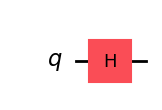

<IPython.core.display.Latex object>

In [54]:
# Ángulos
theta = 0
phi = 0

# Ket ingresado por el usuario
ket = angles_to_ket(theta, phi)
display(ket.draw(output="latex"))

# Puerta a aplicar
qc = QuantumCircuit(1)
qc.h(0)
display(qc.draw(output="mpl"))

# Ket resultante
ket_res = ket.evolve(qc)
display(ket_res.draw(output="latex"))

# Visualización en la esfera de Bloch
plot_bloch_sphere(ket, ket_res, "H")

<IPython.core.display.Latex object>

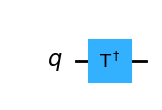

<IPython.core.display.Latex object>

In [55]:
# Ángulos
theta = np.pi/2
phi = np.pi/2

# Ket ingresado por el usuario
ket = angles_to_ket(theta, phi)
display(ket.draw(output="latex"))

# Puerta a aplicar
qc = QuantumCircuit(1)
qc.tdg(0)
display(qc.draw(output="mpl"))

# Ket resultante
ket_res = ket.evolve(qc)
display(ket_res.draw(output="latex"))

# Visualización en la esfera de Bloch
plot_bloch_sphere(ket, ket_res, "H")

---
## <font color='3facc9'> Interactividad </font>

En las siguientes celdas se puede ingresar los ángulos `alpha` y `beta`, seleccionar una puerta y observar el estado inicial, la puerta aplicada, el estado resultante y su representación en la esfera de Bloch.

In [56]:
# Función que toma dos kets Statevector y una puerta, y grafica ambos kets en la esfera de Bloch
def mostrar(alpha, beta, puerta):
    # Ket ingresado por el usuario
    ket = angles_to_ket(alpha, beta)
    # Puerta a aplicar
    qc = QuantumCircuit(1)
    getattr(qc, GATE_METHODS[puerta])(0)
    # Ket resultante
    ket_res = ket.evolve(qc)
    
    # Visualización
    display(Markdown(f'**Ket inicial** para `alpha={alpha:.2f}` y `beta={beta:.2f}`'))
    display(ket.draw(output='latex'))
    
    display(Markdown(f'**Puerta seleccionada:** `{puerta}`'))
    display(qc.draw(output='mpl'))
    
    display(Markdown('**Ket resultante**'))
    display(ket_res.draw(output='latex'))
    
    plot_bloch_sphere(ket, ket_res, puerta)

# Widgets para ángulos y selección de puerta
alpha_widget = widgets.FloatSlider(
    value=0,
    min=0,
    max=np.pi,
    step=0.01,
    description='alpha',
    continuous_update=False,
    readout_format='.2f'
)

beta_widget = widgets.FloatSlider(
    value=0,
    min=0,
    max=2 * np.pi,
    step=0.01,
    description='beta',
    continuous_update=False,
    readout_format='.2f'
)

gate_widget = widgets.Dropdown(
    options=list(GATE_METHODS.keys()),
    value='H',
    description='Puerta'
)

# Salida interactiva
salida_interactiva = widgets.interactive_output(
    mostrar,
    {'alpha': alpha_widget, 'beta': beta_widget, 'puerta': gate_widget}
)

# Mostrar widgets y salida
display(widgets.VBox([
    widgets.HTML('<b>Explora un cúbit sobre la esfera de Bloch</b>'),
    alpha_widget,
    beta_widget,
    gate_widget
]))
display(salida_interactiva)

Output()